# Image Colorization with LAB Space and CNN (Train + Test + Analysis)

In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from keras.models import Model
from keras.layers import Input, Conv2D, UpSampling2D, MaxPooling2D
from keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [3]:
# ==== PARAMETERS ====
IMAGE_SIZE = 256
DATASET_PATH = r"C:\Users\Yash Sud\Downloads\archive\data\train_color"
r"C:\Users\Yash Sud\Downloads\archive\data\train_black"
r"C:\Users\Yash Sud\Downloads\archive\data\test_color"
r"C:\Users\Yash Sud\Downloads\archive\data\test_black" # Set this to your dataset folder

'C:\\Users\\Yash Sud\\Downloads\\archive\\data\\test_black'

In [12]:
# ==== UTILITY: LOAD AND PREPROCESS ====
def preprocess_image(path, size=IMAGE_SIZE):
    img = load_img(path, target_size=(size, size))
    img = img_to_array(img) / 255.0
    lab = cv2.cvtColor(img.astype('float32'), cv2.COLOR_RGB2LAB)
    l = lab[:, :, 0] / 100.0
    ab = (lab[:, :, 1:] + 128) / 255.0
    return l.reshape(size, size, 1), ab.reshape(size, size, 2)

def load_dataset(path, size=IMAGE_SIZE, max_imgs=1000):
    X_l, Y_ab = [], []
    image_files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(('jpg', 'png'))]
    for img_path in tqdm(image_files[:max_imgs], desc="Loading images"):
        try:
            l, ab = preprocess_image(img_path, size)
            X_l.append(l)
            Y_ab.append(ab)
        except:
            continue
    return np.array(X_l), np.array(Y_ab)

In [5]:
# ==== MODEL: U-Net Style CNN ====
def build_colorization_model(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1)):
    input_layer = Input(shape=input_shape)
    x = Conv2D(64, 3, activation='relu', padding='same')(input_layer)
    x = MaxPooling2D()(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D()(x)
    x = Conv2D(256, 3, activation='relu', padding='same')(x)

    x = UpSampling2D()(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = UpSampling2D()(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)

    output_layer = Conv2D(2, 3, activation='tanh', padding='same')(x)

    model = Model(input_layer, output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

In [13]:
# ==== LOAD DATASET ====
X_l, Y_ab = load_dataset(DATASET_PATH)
X_train, X_test, Y_train, Y_test = train_test_split(X_l, Y_ab, test_size=0.1)

Loading images: 100%|██████████████████████████████████████████████████████████████| 1000/1000 [00:34<00:00, 28.70it/s]


In [14]:
# ==== TRAIN MODEL ====
model = build_colorization_model()
history = model.fit(X_train, Y_train, validation_data=(X_test, Y_test), batch_size=8, epochs=50)

Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1096s 10s/step - loss: 0.0340 - val_loss: 0.0033
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1090s 10s/step - loss: 0.0034 - val_loss: 0.0033
Epoch 3/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1692s 15s/step - loss: 0.0035 - val_loss: 0.0043
Epoch 4/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 970s 9s/step - loss: 0.0034 - val_loss: 0.0033
Epoch 5/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 669s 5s/step - loss: 0.0033 - val_loss: 0.0037
Epoch 6/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 530s 5s/step - loss: 0.0034 - val_loss: 0.0038
Epoch 7/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 626s 6s/step - loss: 0.0036 - val_loss: 0.0039
Epoch 8/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1078s 10s/step - loss: 0.0040 - val_loss: 0.0031
Epoch 9/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 1139s 10s/step - loss: 0.0031 - val_loss: 0.0033
Epoch 10/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 9120s 81s/step - loss: 0.0032 - val_loss: 0.0034
Epoch 11/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 27908s 249s/step - loss: 0.0033 - val_loss: 0.0034
Epoch 12/50
113/113 ━━━━━

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 256, 256, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 128, 128, 256)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 128)       │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 256, 256, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 256, 256, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 256, 256, 2)         │           1,154 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,218,952 (8.46 MB)

 Trainable params: 739,650 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,479,302 (5.64 MB)

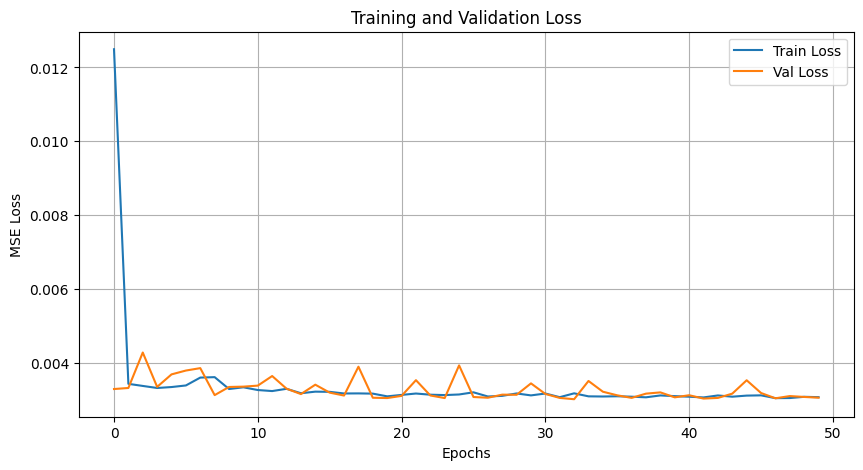


Total Trainable Parameters: 739,650


In [20]:
# ==== ANALYSIS ====
# 1. Summary
model.summary()


# 2. Loss plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# 3. Parameter Count (fixed get_shape issue)
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"\nTotal Trainable Parameters: {trainable_params:,}")

In [21]:
# ==== PREDICT AND SHOW ====
def reconstruct_and_show(input_l, predicted_ab, original_ab=None):
    for i in range(3):  # Show 3 test images
        l_chan = input_l[i][:, :, 0] * 100
        ab_pred = predicted_ab[i] * 255 - 128

        lab_pred = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
        lab_pred[:, :, 0] = l_chan
        lab_pred[:, :, 1:] = ab_pred
        rgb_pred = cv2.cvtColor(lab_pred.astype('float32'), cv2.COLOR_LAB2RGB)

        plt.figure(figsize=(12, 4))

        # Grayscale input
        plt.subplot(1, 3, 1)
        plt.imshow(l_chan, cmap='gray')
        plt.title("Grayscale Input")
        plt.axis('off')

        # Predicted
        plt.subplot(1, 3, 2)
        plt.imshow(rgb_pred)
        plt.title("Predicted Image")
        plt.axis('off')

        # Ground truth
        if original_ab is not None:
            ab_true = original_ab[i] * 255 - 128
            lab_true = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
            lab_true[:, :, 0] = l_chan
            lab_true[:, :, 1:] = ab_true
            rgb_true = cv2.cvtColor(lab_true.astype('float32'), cv2.COLOR_LAB2RGB)

            plt.subplot(1, 3, 3)
            plt.imshow(rgb_true)
            plt.title("Ground Truth")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 9s/step


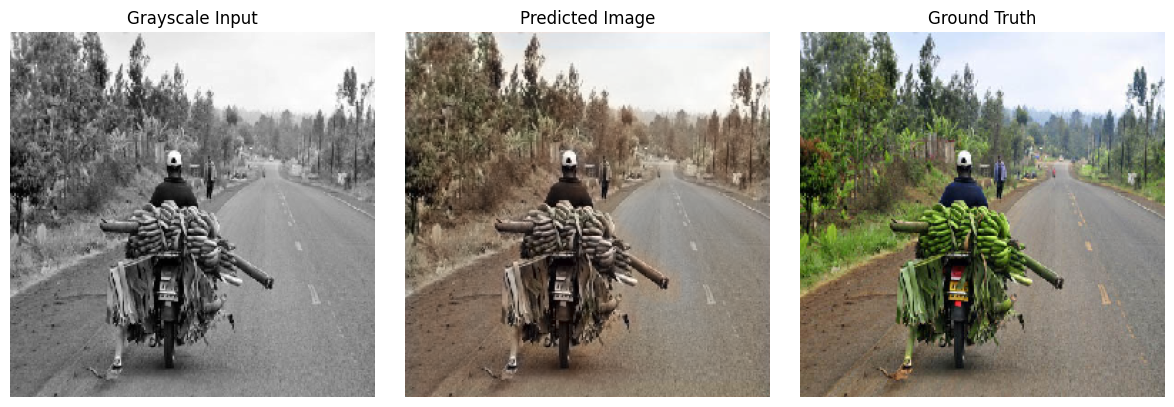

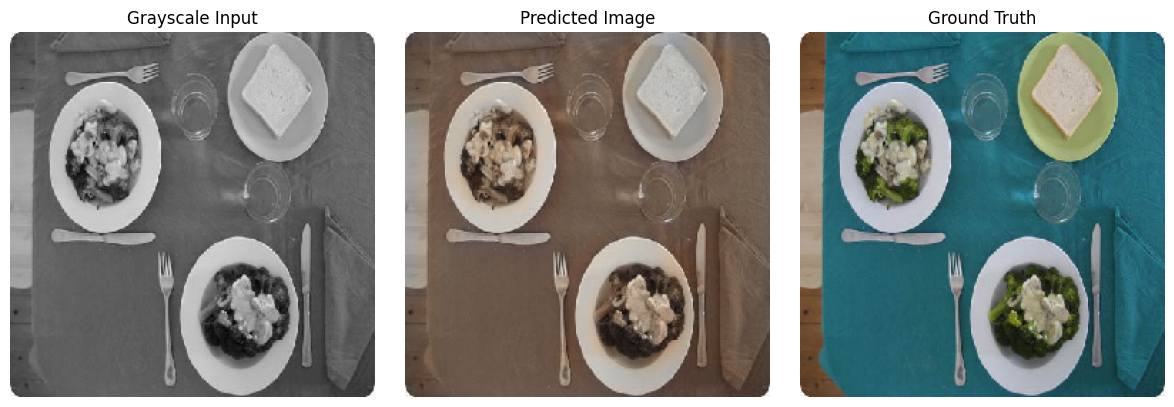

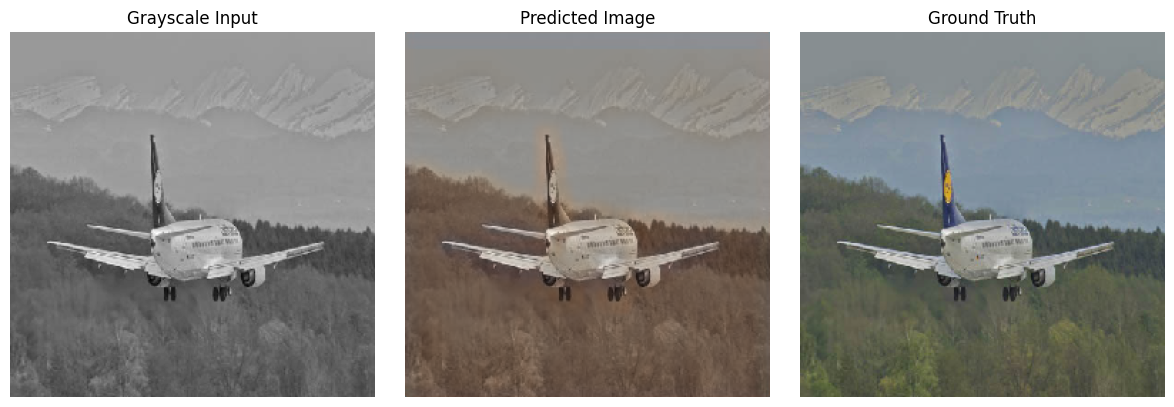

In [22]:

# ==== EXECUTE TEST DISPLAY ====
predicted_ab = model.predict(X_test)
reconstruct_and_show(X_test, predicted_ab, Y_test)

C:\Users\Yash Sud\AppData\Local\Temp\ipykernel_8632\946720300.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Yash Sud\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


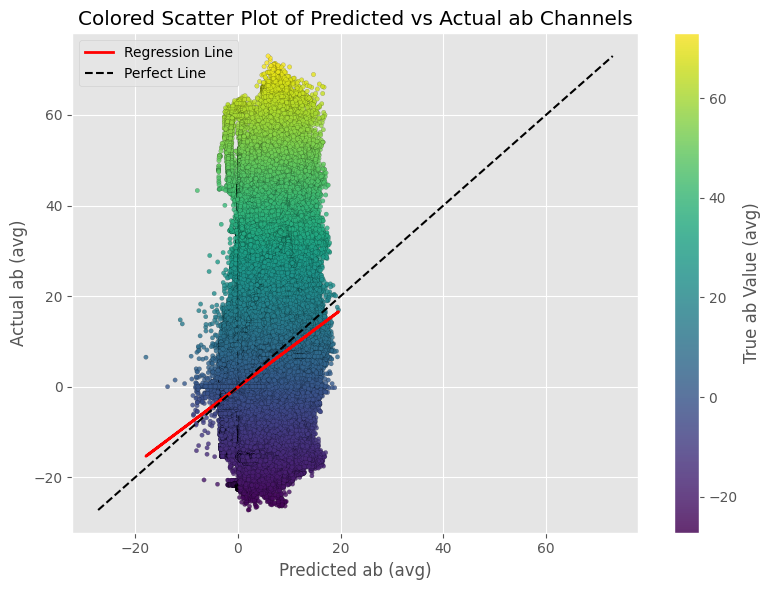

In [40]:
from sklearn.linear_model import LinearRegression

def plot_colored_scatter(Y_true, Y_pred):
    # Denormalize: convert back to [-128, 127]
    Y_true_flat = Y_true.reshape(-1, 2) * 255.0 - 128.0
    Y_pred_flat = Y_pred.reshape(-1, 2) * 255.0 - 128.0

    # Flatten into 1D for scatter (you can also use only one channel like a*, but we'll average here)
    y_true = Y_true_flat.mean(axis=1)
    y_pred = Y_pred_flat.mean(axis=1)

    # Regression line
    reg = LinearRegression().fit(y_pred.reshape(-1, 1), y_true)
    y_fit = reg.predict(y_pred.reshape(-1, 1))

    # Scatter plot with colormap based on actual (true) values
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(y_pred, y_true, c=y_true, cmap='viridis', s=10, alpha=0.8, edgecolors='k', linewidths=0.1)
    plt.plot(y_pred, y_fit, color='red', linewidth=2, label='Regression Line')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', label='Perfect Line')
    
    plt.colorbar(scatter, label='True ab Value (avg)')
    plt.xlabel('Predicted ab (avg)')
    plt.ylabel('Actual ab (avg)')
    plt.title('Colored Scatter Plot of Predicted vs Actual ab Channels')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Call the plot function
plot_colored_scatter(Y_test, predicted_ab)
